# Lab 6 — Encoder-Decoder Architecture and Application
**SVKM's NMIMS | Mukesh Patel School of Technology Management & Engineering**  
**Course: Advanced Topics in Machine Learning | Faculty: Dr. Ami Munshi**

---
### Aim
- Comprehend the concept of Encoder-Decoder Architecture
- Design, implement and train a **deep** Encoder-Decoder for Machine Translation
- Analyze and interpret model performance (BLEU, chrF, Perplexity)
- Build a Next Word Predictor as a real-world application with a Gradio frontend

### Tasks
1. English → Hindi Machine Translation (Kaggle dataset)
2. Evaluate on test set — BLEU score, chrF score, loss curves
3. English → Spanish Machine Translation (HuggingFace `opus_books`)
4. Deep Next Word Predictor — Gradio app

---
> **How to use this notebook (VS Code):**  
> 1. Set `kaggle_csv` in **Cell 2** to the full path of your CSV file  
> 2. Edit any other hyperparameters in **Cell 2** — nothing else needs touching  
> 3. Select your Python environment (top-right in VS Code) that has PyTorch installed  
> 4. Run all cells top-to-bottom — GPU will be used automatically if available

## Cell 1 — Install & Imports

In [18]:
# ── Installations (run once — skip if already installed) ──────────────────────
# Uncomment the line below only if you haven't installed these yet:
import subprocess, sys
pkgs = ['datasets', 'sacrebleu', 'gradio']
for pkg in pkgs:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=True)

import os, re, math, time, random, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

print(f'PyTorch  : {torch.__version__}')
print(f'CUDA     : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU      : {torch.cuda.get_device_name(0)}')
    print(f'VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('Running on CPU — training will be slower. Install CUDA PyTorch for GPU support.')

PyTorch  : 2.7.1+cu118
CUDA     : True
GPU      : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM     : 8.6 GB


## Cell 2 — ⚙️ HYPERPARAMETER CONFIG
**This is the only cell you need to edit.** Every parameter in the entire notebook is controlled from here.

In [6]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║                  HYPERPARAMETER CONFIGURATION BLOCK                    ║
# ║  Edit values here. Every downstream cell reads from CFG automatically. ║
# ╚══════════════════════════════════════════════════════════════════════════╝

CFG = {
    # ┌─ DATA ──────────────────────────────────────────────────────────────┐
    'kaggle_csv'    : r'C:\Users\jaden\Downloads\archive\Hindi_English_Truncated_Corpus.csv',
    # ^ Put the CSV in the same folder as this notebook, OR use a full path:
    # 'kaggle_csv'    : r'C:\Users\YourName\Downloads\Hindi_English_Truncated_Corpus.csv',
    # 'kaggle_csv'    : '/home/yourname/datasets/Hindi_English_Truncated_Corpus.csv',
    'n_samples'       : 50000,   # how many pairs to use  (None = entire file)
    'max_src_len'     : 25,      # drop English sentences longer than this (tokens)
    'max_tgt_len'     : 25,      # drop Hindi sentences longer than this
    'min_word_freq'   : 2,       # words appearing fewer times are mapped to <UNK>
    'train_frac'      : 0.90,    # 90% train
    'val_frac'        : 0.05,    # 5%  val   → remaining 5% is test
    # └─────────────────────────────────────────────────────────────────────┘

    # ┌─ MODEL ARCHITECTURE ────────────────────────────────────────────────┐
    'embed_dim'       : 256,     # embedding dimension (try 128, 256, 512)
    'hidden_dim'      : 512,     # LSTM hidden size    (try 256, 512, 1024)
    'enc_layers'      : 4,       # encoder LSTM depth  (try 2, 3, 4)
    'dec_layers'      : 4,       # decoder LSTM depth  (must equal enc_layers)
    'dropout'         : 0.35,    # dropout rate        (try 0.2 – 0.5)
    'bidir_encoder'   : True,    # bidirectional encoder (True almost always better)
    # └─────────────────────────────────────────────────────────────────────┘

    # ┌─ TRAINING ──────────────────────────────────────────────────────────┐
    'batch_size'      : 128,     # (try 64, 128, 256 — larger = faster but more VRAM)
    'n_epochs'        : 50,      # max epochs (early stopping may stop before this)
    'lr'              : 3e-4,    # initial learning rate (try 1e-4, 3e-4, 1e-3)
    'weight_decay'    : 1e-5,    # AdamW L2 penalty
    'clip_grad'       : 1.0,     # gradient clipping norm
    'label_smoothing' : 0.1,     # label smoothing for CrossEntropyLoss (0 = off)
    'tf_start'        : 0.6,     # teacher forcing ratio at epoch 1
    'tf_end'          : 0.25,    # teacher forcing ratio at final epoch
    'warmup_epochs'   : 3,       # epochs for linear LR warmup before scheduler
    'lr_patience'     : 4,       # ReduceLROnPlateau patience (epochs)
    'lr_factor'       : 0.5,     # LR reduction factor
    'es_patience'     : 8,       # early stopping patience (epochs)
    # └─────────────────────────────────────────────────────────────────────┘

    # ┌─ NEXT WORD PREDICTOR (Language Model) ──────────────────────────────┐
    'lm_context_len'  : 7,       # how many previous words to use as context
    'lm_embed_dim'    : 128,     # LM embedding size
    'lm_hidden_dim'   : 256,     # LM LSTM hidden size
    'lm_layers'       : 3,       # LM LSTM layers
    'lm_dropout'      : 0.35,
    'lm_epochs'       : 200,     # LM training epochs (more = better predictions)
    'lm_lr'           : 1e-3,
    'lm_batch_size'   : 256,
    'lm_top_k'        : 10,      # predictions to show in Gradio
    'lm_min_freq'     : 5,       # minimum word frequency for LM vocabulary
    # └─────────────────────────────────────────────────────────────────────┘

    # ┌─ MISC ──────────────────────────────────────────────────────────────┐
    'seed'            : 42,
    'mt_ckpt'         : 'lab6_mt_best.pt',   # saved MT model
    'lm_ckpt'         : 'lab6_lm_best.pt',   # saved LM
    # └─────────────────────────────────────────────────────────────────────┘
}

# ── Derived constants (auto-computed — do NOT edit below) ──────────────────
PAD, SOS, EOS, UNK = 0, 1, 2, 3

def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CFG['seed'])
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')

# Teacher forcing schedule — linearly interpolated each epoch
def tf_ratio(epoch, n_epochs):
    """Returns teacher forcing ratio for a given epoch (linear decay)."""
    frac = min(epoch / n_epochs, 1.0)
    return CFG['tf_start'] + frac * (CFG['tf_end'] - CFG['tf_start'])

print('\nCFG summary:')
for k, v in CFG.items():
    print(f'  {k:<18} = {v}')

Device : cuda

CFG summary:
  kaggle_csv         = C:\Users\jaden\Downloads\archive\Hindi_English_Truncated_Corpus.csv
  n_samples          = 50000
  max_src_len        = 25
  max_tgt_len        = 25
  min_word_freq      = 2
  train_frac         = 0.9
  val_frac           = 0.05
  embed_dim          = 256
  hidden_dim         = 512
  enc_layers         = 4
  dec_layers         = 4
  dropout            = 0.35
  bidir_encoder      = True
  batch_size         = 128
  n_epochs           = 50
  lr                 = 0.0003
  weight_decay       = 1e-05
  clip_grad          = 1.0
  label_smoothing    = 0.1
  tf_start           = 0.6
  tf_end             = 0.25
  warmup_epochs      = 3
  lr_patience        = 4
  lr_factor          = 0.5
  es_patience        = 8
  lm_context_len     = 7
  lm_embed_dim       = 128
  lm_hidden_dim      = 256
  lm_layers          = 3
  lm_dropout         = 0.35
  lm_epochs          = 200
  lm_lr              = 0.001
  lm_batch_size      = 256
  lm_top_k           =

## Cell 3 — Text Preprocessing Helpers

In [7]:
def clean_en(text):
    """Lowercase, keep ASCII letters/digits/apostrophes, collapse whitespace."""
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9\s']", ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def clean_hi(text):
    """
    Keep the full Devanagari Unicode range (U+0900–U+097F) plus
    Devanagari Extended (U+A8E0–U+A8FF), Vedic (U+1CD0–U+1CFF),
    digits, and whitespace. Handles all standard Hindi encodings.
    """
    text = str(text).strip()
    # Keep Devanagari block + extended + digits + spaces
    text = re.sub(
        r'[^\u0900-\u097F\u0966-\u096F\uA8E0-\uA8FF\u1CD0-\u1CFF0-9\s]',
        ' ', text
    )
    return re.sub(r'\s+', ' ', text).strip()

def clean_es(text):
    """Spanish: lowercase, keep accented characters."""
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z\u00e0-\u00ff0-9\s']", ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

# Smoke tests
print('EN:', clean_en('Hello, World! How are you?'))
print('HI:', clean_hi('नमस्ते। आप कैसे हैं?'))
print('ES:', clean_es('¡Hola, señor! ¿Cómo estás?'))

# Verify Devanagari is preserved
test_hi = 'आप कैसे हैं'
cleaned = clean_hi(test_hi)
assert len(cleaned) > 0, 'ERROR: clean_hi is stripping all Devanagari — encoding issue!'
print(f'\nDevanagari preservation check: "{test_hi}" → "{cleaned}" ✓')

EN: hello world how are you
HI: नमस्ते। आप कैसे हैं
ES: hola señor cómo estás

Devanagari preservation check: "आप कैसे हैं" → "आप कैसे हैं" ✓


## Cell 4 — Load Kaggle CSV (English–Hindi)

**Place the CSV in the same folder as this notebook**, or set the full path in `CFG['kaggle_csv']` in Cell 2.  
Dataset: https://www.kaggle.com/datasets/aiswaryaramachandran/hindienglish-corpora  
Expected CSV columns: `english_sentence`, `hindi_sentence`

In [8]:
# ── Read CSV from local path set in CFG ───────────────────────────────────────
import os
assert os.path.exists(CFG['kaggle_csv']), (
    f"CSV not found at: '{CFG['kaggle_csv']}\n"
    "Either place the CSV in the same folder as this notebook, "
    "or update CFG['kaggle_csv'] in Cell 2 with the full path."
)

df_raw = pd.read_csv(CFG['kaggle_csv'])
print(f'Raw shape   : {df_raw.shape}')
print(f'Columns     : {list(df_raw.columns)}')
df_raw.head(3)

Raw shape   : (127607, 3)
Columns     : ['source', 'english_sentence', 'hindi_sentence']


,source,english_sentence,hindi_sentence
0,ted,politicians do not have permission to do what ...,"राजनीतिज्ञों के पास जो कार्य करना चाहिए, वह कर..."
1,ted,"I'd like to tell you about one such child,",मई आपको ऐसे ही एक बच्चे के बारे में बताना चाहू...
2,indic2012,This percentage is even greater than the perce...,यह प्रतिशत भारत में हिन्दुओं प्रतिशत से अधिक है।


## Cell 5 — Clean & Filter Dataset

All columns in CSV:
  [0] "source"  →  sample: ted
  [1] "english_sentence"  →  sample: politicians do not have permission to do what needs to be do
  [2] "hindi_sentence"  →  sample: राजनीतिज्ञों के पास जो कार्य करना चाहिए, वह करने कि अनुमति न

Using columns:
  English → "english_sentence"
  Hindi   → "hindi_sentence"

First 3 raw rows of these columns:
                                                  english_sentence                                                        hindi_sentence
0  politicians do not have permission to do what needs to be done.  राजनीतिज्ञों के पास जो कार्य करना चाहिए, वह करने कि अनुमति नहीं है .
1                       I'd like to tell you about one such child,                    मई आपको ऐसे ही एक बच्चे के बारे में बताना चाहूंगी,
2    This percentage is even greater than the percentage in India.                      यह प्रतिशत भारत में हिन्दुओं प्रतिशत से अधिक है।

Rows after dropping nulls/empty : 127,605
After cleaning — empty English rows : 45
After clean

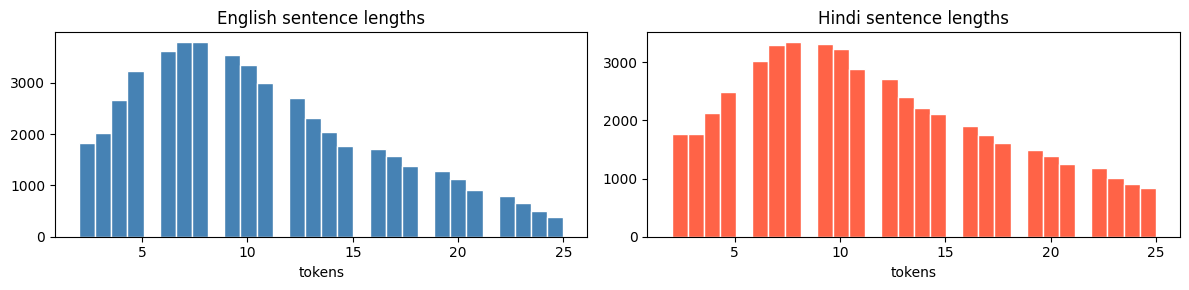


Sample pairs (after cleaning):
  EN: so the value of his life was the sum total
  HI: और उसके सारी जीवन का मूल्य इस एक जीवन में अर्जित

  EN: we are not among those who try everything yet reach nowhere
  HI: हम उन लगों में नहीं जो हर चीज आजमाते हैं और कहीं नहीं फंचते

  EN: view this too
  HI: यह भी देखें

  EN: besides no time frame has been specified for submitting the report
  HI: इसके अलवा रिपोर्ट पेश करने की कोई समय सीमा तय नहीं की गई है

  EN: dutt family was considered to be a reputed family in kolkata
  HI: दत्त परिवार को कोलकाता का एक कुलीन परिवार माना जाता था।



In [9]:
# ── Step 1: Show all columns so we can see what we're working with ─────────────
print('All columns in CSV:')
for i, c in enumerate(df_raw.columns):
    print(f'  [{i}] "{c}"  →  sample: {str(df_raw[c].iloc[0])[:60]}')

# ── Step 2: Identify English and Hindi columns ─────────────────────────────────
# Try by keyword first, then fall back to positional (col 0 = EN, col 1 = HI)
cols_lower = {c: c.lower() for c in df_raw.columns}

en_col = next(
    (c for c, cl in cols_lower.items() if 'english' in cl or 'en_' in cl or cl == 'en'),
    df_raw.columns[0]   # fallback: first column
)
hi_col = next(
    (c for c, cl in cols_lower.items()
     if ('hindi' in cl or 'hi_' in cl or cl == 'hi')
     and c != en_col),
    [c for c in df_raw.columns if c != en_col][0]  # fallback: second column
)

print(f'\nUsing columns:')
print(f'  English → "{en_col}"')
print(f'  Hindi   → "{hi_col}"')
print(f'\nFirst 3 raw rows of these columns:')
print(df_raw[[en_col, hi_col]].head(3).to_string())

# ── Step 3: Extract and drop nulls ────────────────────────────────────────────
df = df_raw[[en_col, hi_col]].dropna().copy()
df.columns = ['en', 'hi']
df = df[(df['en'].astype(str).str.strip() != '') &
        (df['hi'].astype(str).str.strip() != '')].copy()
print(f'\nRows after dropping nulls/empty : {len(df):,}')

# ── Step 4: Clean text ────────────────────────────────────────────────────────
df['en'] = df['en'].apply(clean_en)
df['hi'] = df['hi'].apply(clean_hi)

# Sanity-check cleaning: make sure Hindi wasn't wiped
hi_empty = (df['hi'].str.strip() == '').sum()
en_empty = (df['en'].str.strip() == '').sum()
print(f'After cleaning — empty English rows : {en_empty:,}')
print(f'After cleaning — empty Hindi rows   : {hi_empty:,}')
if hi_empty > len(df) * 0.5:
    print('\n⚠️  WARNING: More than 50% of Hindi rows are empty after cleaning.')
    print('   This usually means the Hindi column contains romanised text, not Devanagari.')
    print('   Showing sample raw Hindi values:')
    print(df_raw[hi_col].head(5).tolist())

# Drop rows emptied by cleaning
df = df[(df['en'].str.strip() != '') & (df['hi'].str.strip() != '')].copy()
print(f'Rows after cleaning empty rows   : {len(df):,}')

# ── Step 5: Length filter ─────────────────────────────────────────────────────
df['en_len'] = df['en'].str.split().str.len()
df['hi_len'] = df['hi'].str.split().str.len()

print(f'\nBefore length filter : {len(df):,} rows')
print(f'  EN length range    : {df["en_len"].min()} – {df["en_len"].max()}')
print(f'  HI length range    : {df["hi_len"].min()} – {df["hi_len"].max()}')
print(f'  Filtering to EN ≤ {CFG["max_src_len"]} and HI ≤ {CFG["max_tgt_len"]} tokens...')

df = df[
    df['en_len'].between(2, CFG['max_src_len']) &
    df['hi_len'].between(2, CFG['max_tgt_len'])
].reset_index(drop=True)
print(f'After length filter  : {len(df):,} rows')

assert len(df) > 0, (
    'ERROR: 0 rows remain after filtering!\n'
    'Check the printed column samples above.\n'
    'If Hindi column shows Roman text (not Devanagari), the dataset has a different structure.'
)

# ── Step 6: Sample ────────────────────────────────────────────────────────────
if CFG['n_samples'] and CFG['n_samples'] < len(df):
    df = df.sample(n=CFG['n_samples'], random_state=CFG['seed']).reset_index(drop=True)

print(f'\n✅ Final dataset size : {len(df):,} pairs')
print('\nLength statistics:')
print(df[['en_len', 'hi_len']].describe().round(2))

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].hist(df['en_len'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('English sentence lengths'); axes[0].set_xlabel('tokens')
axes[1].hist(df['hi_len'], bins=30, color='tomato', edgecolor='white')
axes[1].set_title('Hindi sentence lengths');   axes[1].set_xlabel('tokens')
plt.tight_layout(); plt.show()

print('\nSample pairs (after cleaning):')
for _, row in df.head(5).iterrows():
    print(f'  EN: {row["en"]}')
    print(f'  HI: {row["hi"]}\n')

## Cell 6 — Vocabulary

In [10]:
class Vocabulary:
    """
    Builds a word-to-index mapping from a list of sentences.
    Special tokens: <PAD>=0  <SOS>=1  <EOS>=2  <UNK>=3
    Words appearing fewer than min_freq times are treated as <UNK>.
    """
    def __init__(self, name, min_freq=1):
        self.name     = name
        self.min_freq = min_freq
        self.word2idx = {'<PAD>': PAD, '<SOS>': SOS, '<EOS>': EOS, '<UNK>': UNK}
        self.idx2word = {PAD: '<PAD>', SOS: '<SOS>', EOS: '<EOS>', UNK: '<UNK>'}
        self.n_words  = 4
        self.freqs    = Counter()

    def build(self, sentences):
        for s in sentences:
            self.freqs.update(s.split())
        kept = 0
        for word, freq in self.freqs.items():
            if freq >= self.min_freq:
                self._add(word)
                kept += 1
        print(f'  [{self.name}] vocab size = {self.n_words:,}  '
              f'(kept {kept:,} / {len(self.freqs):,} unique words, min_freq={self.min_freq})')

    def _add(self, word):
        if word not in self.word2idx:
            self.word2idx[word] = self.n_words
            self.idx2word[self.n_words] = word
            self.n_words += 1

    def encode(self, sentence, add_eos=True):
        """Sentence string → list of token IDs."""
        ids = [self.word2idx.get(w, UNK) for w in sentence.split()]
        return ids + [EOS] if add_eos else ids

    def decode(self, ids):
        """List of token IDs → sentence string (stops at EOS, skips PAD/SOS)."""
        out = []
        for i in ids:
            if i == EOS: break
            if i not in {PAD, SOS, UNK}:
                out.append(self.idx2word.get(i, '<UNK>'))
        return ' '.join(out)


src_vocab = Vocabulary('English', CFG['min_word_freq'])
tgt_vocab = Vocabulary('Hindi',   CFG['min_word_freq'])
src_vocab.build(df['en'])
tgt_vocab.build(df['hi'])

  [English] vocab size = 17,340  (kept 17,336 / 33,783 unique words, min_freq=2)
  [Hindi] vocab size = 20,502  (kept 20,498 / 37,005 unique words, min_freq=2)


## Cell 7 — Dataset & DataLoaders

In [11]:
class TranslationDataset(Dataset):
    """Stores pre-encoded (src_ids, tgt_ids) pairs."""
    def __init__(self, pairs, src_v, tgt_v):
        self.data = [
            (src_v.encode(en, add_eos=True),
             tgt_v.encode(hi, add_eos=True))
            for en, hi in pairs
        ]

    def __len__(self):          return len(self.data)
    def __getitem__(self, idx): return self.data[idx]


def collate_fn(batch):
    """
    Pads variable-length sequences within a batch.
    Returns:
      src_pad  : (B, S)   padded source token IDs
      src_lens : (B,)     actual lengths (for pack_padded_sequence)
      tgt_pad  : (B, T+1) target with <SOS> prepended
    """
    src_seqs, tgt_seqs = zip(*batch)
    src_lens = torch.tensor([len(s) for s in src_seqs])
    max_src  = src_lens.max().item()
    max_tgt  = max(len(t) for t in tgt_seqs) + 1     # +1 for <SOS>

    src_pad = torch.zeros(len(batch), max_src, dtype=torch.long)
    tgt_pad = torch.zeros(len(batch), max_tgt, dtype=torch.long)

    for i, (s, t) in enumerate(zip(src_seqs, tgt_seqs)):
        src_pad[i, :len(s)]       = torch.tensor(s)
        tgt_pad[i, 0]             = SOS
        tgt_pad[i, 1 : len(t)+1] = torch.tensor(t)

    return src_pad, src_lens, tgt_pad


# ── Train / Val / Test split ───────────────────────────────────────────────────
all_pairs = list(zip(df['en'], df['hi']))
random.shuffle(all_pairs)

N      = len(all_pairs)
n_tr   = int(N * CFG['train_frac'])
n_val  = int(N * CFG['val_frac'])
train_pairs = all_pairs[:n_tr]
val_pairs   = all_pairs[n_tr : n_tr + n_val]
test_pairs  = all_pairs[n_tr + n_val :]

def build_loader(pairs, batch_size, shuffle):
    ds = TranslationDataset(pairs, src_vocab, tgt_vocab)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      collate_fn=collate_fn, num_workers=0, pin_memory=False)

train_loader = build_loader(train_pairs, CFG['batch_size'],   shuffle=True)
val_loader   = build_loader(val_pairs,   CFG['batch_size']*2, shuffle=False)
test_loader  = build_loader(test_pairs,  CFG['batch_size']*2, shuffle=False)

print(f'Train : {len(train_pairs):>7,} pairs  ({len(train_loader):,} batches)')
print(f'Val   : {len(val_pairs):>7,} pairs')
print(f'Test  : {len(test_pairs):>7,} pairs')

Train :  45,000 pairs  (352 batches)
Val   :   2,500 pairs
Test  :   2,500 pairs


## Cell 8 — Model Architecture

```
Encoder  : Embedding → LayerNorm → Dropout → N-layer Bidirectional LSTM
           → Project (H×2 → H) for both hidden & cell

Decoder  : Embedding → Dropout
           LSTM input = [embedding ‖ encoder_context]      (E + H)
           Output projection = [lstm_out ‖ context ‖ emb]  (H + H + E)
                             → Linear → GELU → LayerNorm → Linear → vocab

Seq2Seq  : Encoder → context = top-layer hidden
           Decoder unrolled with teacher forcing schedule
```

In [12]:
# ──────────────────────────────────────────────────────────────────────────────
# ENCODER
# ──────────────────────────────────────────────────────────────────────────────
class Encoder(nn.Module):
    """
    Deep (multi-layer) optionally bidirectional LSTM encoder.

    Key design points:
    - LayerNorm on embeddings stabilises early training
    - pack_padded_sequence skips PAD tokens → faster + correct gradients
    - Bidirectional: forward & backward hidden/cell are concatenated then
      projected back to hidden_dim via a learned linear layer so the decoder
      can use the same hidden_dim regardless
    - Orthogonal init for recurrent weights, Xavier for input-hidden weights
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 n_layers, dropout, bidirectional=True):
        super().__init__()
        self.n_layers      = n_layers
        self.hidden_dim    = hidden_dim
        self.bidirectional = bidirectional
        nd = 2 if bidirectional else 1

        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        self.emb_norm   = nn.LayerNorm(embed_dim)
        self.emb_drop   = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            input_size    = embed_dim,
            hidden_size   = hidden_dim,
            num_layers    = n_layers,
            dropout       = dropout if n_layers > 1 else 0.0,
            batch_first   = True,
            bidirectional = bidirectional,
        )

        if bidirectional:
            # Project bidirectional hidden & cell to hidden_dim
            self.fc_hidden = nn.Linear(hidden_dim * 2, hidden_dim)
            self.fc_cell   = nn.Linear(hidden_dim * 2, hidden_dim)

        self._init_weights()

    def _init_weights(self):
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        nn.init.constant_(self.embedding.weight[PAD], 0)  # PAD stays zero
        for name, param in self.lstm.named_parameters():
            if   'weight_ih' in name: nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name: nn.init.orthogonal_(param)
            elif 'bias'      in name: nn.init.zeros_(param)

    def forward(self, src, src_lens):
        """
        src      : (B, S)  token IDs
        src_lens : (B,)    true lengths
        returns:
          enc_out  : (B, S, H*nd)  all hidden states
          hidden   : (n_layers, B, H)
          cell     : (n_layers, B, H)
        """
        emb    = self.emb_drop(self.emb_norm(self.embedding(src)))   # (B, S, E)
        packed = pack_padded_sequence(emb, src_lens.cpu(),
                                      batch_first=True, enforce_sorted=False)
        packed_out, (h, c) = self.lstm(packed)
        enc_out, _ = pad_packed_sequence(packed_out, batch_first=True)  # (B, S, H*nd)

        if self.bidirectional:
            # h shape: (n_layers*2, B, H) → reshape → concat directions → project
            def merge_bidir(t, fc):
                t  = t.view(self.n_layers, 2, t.shape[1], self.hidden_dim)
                fw = t[:, 0, :, :]   # (layers, B, H)
                bw = t[:, 1, :, :]   # (layers, B, H)
                return torch.tanh(fc(torch.cat([fw, bw], dim=-1)))  # (layers, B, H)

            h = merge_bidir(h, self.fc_hidden)
            c = merge_bidir(c, self.fc_cell)

        return enc_out, h, c


# ──────────────────────────────────────────────────────────────────────────────
# DECODER
# ──────────────────────────────────────────────────────────────────────────────
class Decoder(nn.Module):
    """
    Deep multi-layer LSTM Decoder.

    LSTM receives [embedding ‖ encoder_context] at each step, giving it
    direct access to source information at every position.

    Output projection concatenates three signals before the final linear:
        [lstm_output ‖ encoder_context ‖ current_embedding]
    This 3-way concat is a well-known trick (similar to input-feeding in
    attention models) that helps the decoder maintain source awareness.

    Two-layer GELU projection with LayerNorm for depth and stability.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.hidden_dim = hidden_dim

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD)
        self.emb_drop  = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            input_size  = embed_dim + hidden_dim,   # emb + context
            hidden_size = hidden_dim,
            num_layers  = n_layers,
            dropout     = dropout if n_layers > 1 else 0.0,
            batch_first = True,
        )

        # Deep output projection
        proj_in = hidden_dim + hidden_dim + embed_dim
        self.output_proj = nn.Sequential(
            nn.Linear(proj_in,        hidden_dim * 2),
            nn.GELU(),
            nn.LayerNorm(hidden_dim * 2),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden_dim,     vocab_size),
        )

        self._init_weights()

    def _init_weights(self):
        nn.init.uniform_(self.embedding.weight, -0.1, 0.1)
        nn.init.constant_(self.embedding.weight[PAD], 0)
        for name, param in self.lstm.named_parameters():
            if   'weight_ih' in name: nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name: nn.init.orthogonal_(param)
            elif 'bias'      in name: nn.init.zeros_(param)
        for layer in self.output_proj:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward_step(self, token, hidden, cell, context):
        """
        One decoding step.
        token   : (B,)        current input token ID
        hidden  : (L, B, H)   decoder hidden state
        cell    : (L, B, H)   decoder cell state
        context : (B, H)      encoder context (top-layer final hidden)
        returns: logits (B, V), updated hidden, updated cell
        """
        emb     = self.emb_drop(self.embedding(token.unsqueeze(1)))  # (B, 1, E)
        ctx     = context.unsqueeze(1)                                # (B, 1, H)
        rnn_in  = torch.cat([emb, ctx], dim=-1)                       # (B, 1, E+H)

        out, (hidden, cell) = self.lstm(rnn_in, (hidden, cell))       # out: (B,1,H)

        proj_in = torch.cat([
            out.squeeze(1),    # lstm output           (B, H)
            context,           # encoder context       (B, H)
            emb.squeeze(1),    # current embedding     (B, E)
        ], dim=-1)             #                       (B, H+H+E)

        logits = self.output_proj(proj_in)   # (B, V)
        return logits, hidden, cell


# ──────────────────────────────────────────────────────────────────────────────
# SEQ2SEQ
# ──────────────────────────────────────────────────────────────────────────────
class Seq2Seq(nn.Module):
    """
    Puts encoder and decoder together.
    Teacher forcing: with probability tf_ratio use ground-truth token;
    otherwise feed model's own prediction. Ratio decays over training.
    """
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device  = device

    def forward(self, src, src_lens, tgt, tf_ratio=0.5):
        """
        src      : (B, S)
        src_lens : (B,)
        tgt      : (B, T)   starts with <SOS>, ends with <EOS>
        tf_ratio : float    teacher forcing probability
        returns  : outputs (B, T, V)
        """
        B, T = tgt.shape
        V    = self.decoder.output_proj[-1].out_features

        outputs = torch.zeros(B, T, V, device=self.device)

        enc_out, hidden, cell = self.encoder(src, src_lens)
        context = hidden[-1]    # top encoder layer hidden: (B, H)
        token   = tgt[:, 0]     # first input = <SOS>

        for t in range(1, T):
            logits, hidden, cell = self.decoder.forward_step(
                token, hidden, cell, context
            )
            outputs[:, t] = logits
            # Teacher forcing decision
            use_teacher = random.random() < tf_ratio
            token = tgt[:, t] if use_teacher else logits.argmax(dim=-1)

        return outputs


# ── Build models ───────────────────────────────────────────────────────────────
encoder = Encoder(
    vocab_size    = src_vocab.n_words,
    embed_dim     = CFG['embed_dim'],
    hidden_dim    = CFG['hidden_dim'],
    n_layers      = CFG['enc_layers'],
    dropout       = CFG['dropout'],
    bidirectional = CFG['bidir_encoder'],
).to(DEVICE)

decoder = Decoder(
    vocab_size = tgt_vocab.n_words,
    embed_dim  = CFG['embed_dim'],
    hidden_dim = CFG['hidden_dim'],
    n_layers   = CFG['dec_layers'],
    dropout    = CFG['dropout'],
).to(DEVICE)

model = Seq2Seq(encoder, decoder, DEVICE).to(DEVICE)

enc_p = sum(p.numel() for p in encoder.parameters())
dec_p = sum(p.numel() for p in decoder.parameters())
print('Model summary')
print('─' * 45)
print(f'  Encoder layers    : {CFG["enc_layers"]}  (bidirectional={CFG["bidir_encoder"]})')
print(f'  Decoder layers    : {CFG["dec_layers"]}')
print(f'  Embed dim         : {CFG["embed_dim"]}')
print(f'  Hidden dim        : {CFG["hidden_dim"]}')
print(f'  Dropout           : {CFG["dropout"]}')
print(f'  Encoder params    : {enc_p:>10,}')
print(f'  Decoder params    : {dec_p:>10,}')
print(f'  Total params      : {enc_p+dec_p:>10,}')
print(f'  Source vocab      : {src_vocab.n_words:>10,}')
print(f'  Target vocab      : {tgt_vocab.n_words:>10,}')

Model summary
─────────────────────────────────────────────
  Encoder layers    : 4  (bidirectional=True)
  Decoder layers    : 4
  Embed dim         : 256
  Hidden dim        : 512
  Dropout           : 0.35
  Encoder params    : 27,542,016
  Decoder params    : 26,533,910
  Total params      : 54,075,926
  Source vocab      :     17,340
  Target vocab      :     20,502


## Cell 9 — Training Utilities

In [13]:
criterion = nn.CrossEntropyLoss(
    ignore_index    = PAD,
    label_smoothing = CFG['label_smoothing'],
)

optimizer = optim.AdamW(
    model.parameters(),
    lr           = CFG['lr'],
    weight_decay = CFG['weight_decay'],
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode     = 'min',
    patience = CFG['lr_patience'],
    factor   = CFG['lr_factor'],
)


def compute_loss(logits, tgt):
    """Flatten (B,T,V) and (B,T) then compute cross-entropy, ignoring t=0 (<SOS>)."""
    return criterion(
        logits[:, 1:, :].reshape(-1, logits.shape[-1]),
        tgt[:, 1:].reshape(-1),
    )


def train_one_epoch(model, loader, optimizer, tf):
    model.train()
    total_loss, n_batches = 0.0, 0
    for src, src_lens, tgt in loader:
        src  = src.to(DEVICE)
        tgt  = tgt.to(DEVICE)
        optimizer.zero_grad()
        logits = model(src, src_lens, tgt, tf_ratio=tf)
        loss   = compute_loss(logits, tgt)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CFG['clip_grad'])
        optimizer.step()
        total_loss += loss.item()
        n_batches  += 1
    return total_loss / n_batches


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, n_batches = 0.0, 0
    for src, src_lens, tgt in loader:
        src = src.to(DEVICE)
        tgt = tgt.to(DEVICE)
        logits = model(src, src_lens, tgt, tf_ratio=0.0)   # no teacher forcing at eval
        total_loss += compute_loss(logits, tgt).item()
        n_batches  += 1
    return total_loss / n_batches


print('Criterion  :', criterion)
print('Optimizer  :', type(optimizer).__name__,
      f'lr={CFG["lr"]}  wd={CFG["weight_decay"]}')
print('Scheduler  : ReduceLROnPlateau',
      f'patience={CFG["lr_patience"]}  factor={CFG["lr_factor"]}')
print(f'TF start→end : {CFG["tf_start"]} → {CFG["tf_end"]}  (linear decay)')

Criterion  : CrossEntropyLoss()
Optimizer  : AdamW lr=0.0003  wd=1e-05
Scheduler  : ReduceLROnPlateau patience=4  factor=0.5
TF start→end : 0.6 → 0.25  (linear decay)


## Cell 10 — Train MT Model (Task 1)

In [14]:
history = {'train_loss': [], 'val_loss': [], 'lr': [], 'tf': []}
best_val_loss  = float('inf')
best_state     = None
patience_count = 0

HDR = (f'{'Epoch':>6}  {'Train Loss':>11}  {'Val Loss':>10}  '
       f'{'Val PPL':>8}  {'LR':>10}  {'TF':>6}  {'Time':>7}')
print(f'Training for up to {CFG["n_epochs"]} epochs  '
      f'(early stop patience={CFG["es_patience"]})')
print(HDR)
print('─' * 74)

for epoch in range(1, CFG['n_epochs'] + 1):
    t0  = time.time()
    cur_tf = tf_ratio(epoch, CFG['n_epochs'])

    # ── LR warmup (linear ramp for first warmup_epochs) ───────────────────
    if epoch <= CFG['warmup_epochs']:
        warmup_lr = CFG['lr'] * epoch / CFG['warmup_epochs']
        for pg in optimizer.param_groups:
            pg['lr'] = warmup_lr

    train_loss = train_one_epoch(model, train_loader, optimizer, cur_tf)
    val_loss   = evaluate(model, val_loader)

    # ── Step scheduler only after warmup ──────────────────────────────────
    if epoch > CFG['warmup_epochs']:
        scheduler.step(val_loss)

    cur_lr  = optimizer.param_groups[0]['lr']
    val_ppl = math.exp(min(val_loss, 10))
    elapsed = time.time() - t0

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['lr'].append(cur_lr)
    history['tf'].append(cur_tf)

    # ── Checkpoint ────────────────────────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        patience_count = 0
        best_state     = copy.deepcopy(model.state_dict())
        torch.save({
            'model_state' : best_state,
            'src_vocab'   : src_vocab,
            'tgt_vocab'   : tgt_vocab,
            'cfg'         : CFG,
            'epoch'       : epoch,
        }, CFG['mt_ckpt'])
        tag = '  ✓ best'
    else:
        patience_count += 1
        tag = f'  ({patience_count}/{CFG["es_patience"]})'

    print(f'{epoch:>6}  {train_loss:>11.4f}  {val_loss:>10.4f}  '
          f'{val_ppl:>8.2f}  {cur_lr:>10.2e}  {cur_tf:>6.3f}  '
          f'{elapsed:>5.1f}s{tag}')

    if patience_count >= CFG['es_patience']:
        print(f'\n⏹  Early stopping triggered at epoch {epoch}')
        break

# Restore best checkpoint
model.load_state_dict(best_state)
print(f'\n✅ Training complete')
print(f'   Best val loss : {best_val_loss:.4f}')
print(f'   Best val PPL  : {math.exp(min(best_val_loss, 10)):.2f}')

Training for up to 50 epochs  (early stop patience=8)
 Epoch   Train Loss    Val Loss   Val PPL          LR      TF     Time
──────────────────────────────────────────────────────────────────────────
     1       7.3758      7.1085   1222.31    1.00e-04   0.593  111.9s  ✓ best
     2       6.8600      6.9642   1058.02    2.00e-04   0.586  118.7s  ✓ best
     3       6.5342      6.8098    906.68    3.00e-04   0.579  117.3s  ✓ best
     4       6.2374      6.7162    825.68    3.00e-04   0.572  118.6s  ✓ best
     5       6.0169      6.5957    731.95    3.00e-04   0.565  119.0s  ✓ best
     6       5.8037      6.5485    698.18    3.00e-04   0.558  119.0s  ✓ best
     7       5.6315      6.4812    652.76    3.00e-04   0.551  114.7s  ✓ best
     8       5.4636      6.4327    621.88    3.00e-04   0.544  119.2s  ✓ best
     9       5.3229      6.4121    609.15    3.00e-04   0.537  118.2s  ✓ best
    10       5.1892      6.3680    582.91    3.00e-04   0.530  122.6s  ✓ best
    11       5.0619 

## Cell 11 — Training Curves

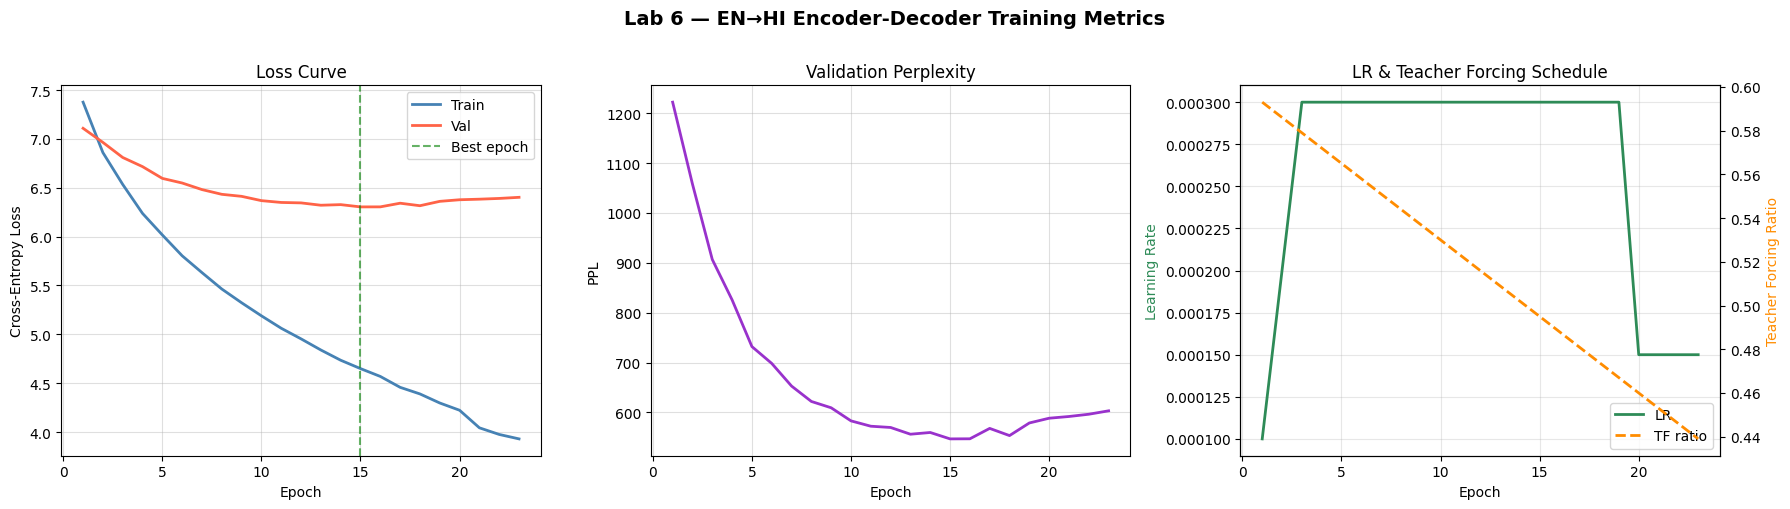

Saved: lab6_training_curves.png


In [15]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# Loss
ax1.plot(epochs_ran, history['train_loss'], label='Train', color='steelblue', lw=2)
ax1.plot(epochs_ran, history['val_loss'],   label='Val',   color='tomato',    lw=2)
ax1.axvline(history['val_loss'].index(min(history['val_loss']))+1,
            color='green', ls='--', alpha=0.6, label='Best epoch')
ax1.set_title('Loss Curve',       fontsize=12); ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss'); ax1.legend(); ax1.grid(alpha=0.4)

# Perplexity
val_ppl = [math.exp(min(v, 10)) for v in history['val_loss']]
ax2.plot(epochs_ran, val_ppl, color='darkorchid', lw=2)
ax2.set_title('Validation Perplexity', fontsize=12); ax2.set_xlabel('Epoch')
ax2.set_ylabel('PPL'); ax2.grid(alpha=0.4)

# LR + TF ratio on twin axes
ax3.plot(epochs_ran, history['lr'], color='seagreen', lw=2, label='LR')
ax3.set_ylabel('Learning Rate', color='seagreen'); ax3.set_xlabel('Epoch')
twin = ax3.twinx()
twin.plot(epochs_ran, history['tf'], color='darkorange', lw=2, ls='--', label='TF ratio')
twin.set_ylabel('Teacher Forcing Ratio', color='darkorange')
ax3.set_title('LR & Teacher Forcing Schedule', fontsize=12)
ax3.grid(alpha=0.3)
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2)

plt.suptitle('Lab 6 — EN→HI Encoder-Decoder Training Metrics',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('lab6_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: lab6_training_curves.png')

## Cell 12 — Inference & Evaluation (Task 2)
BLEU and chrF scores on the held-out test set.

In [16]:
@torch.no_grad()
def translate(sentence, src_v=src_vocab, tgt_v=tgt_vocab,
              m=None, max_len=60):
    """Greedy decoding for a single sentence."""
    if m is None: m = model
    m.eval()

    clean = clean_en(sentence)
    src_ids  = torch.tensor(src_v.encode(clean, add_eos=True),
                             dtype=torch.long).unsqueeze(0).to(DEVICE)
    src_lens = torch.tensor([src_ids.shape[1]])

    _, hidden, cell = m.encoder(src_ids, src_lens)
    context = hidden[-1]                               # top layer
    token   = torch.tensor([SOS], device=DEVICE)
    output_ids = []

    for _ in range(max_len):
        logits, hidden, cell = m.decoder.forward_step(token, hidden, cell, context)
        pred = logits.argmax(dim=-1)
        if pred.item() == EOS:
            break
        output_ids.append(pred.item())
        token = pred

    return tgt_v.decode(output_ids)


# ── Sample translations ────────────────────────────────────────────────────────
print('Sample translations from test set:')
print(f'  {"English":<38}  {"Ground Truth":<30}  Prediction')
print('  ' + '─' * 105)
for en, hi in test_pairs[:20]:
    pred = translate(en)
    match = '✓' if pred.strip() == hi.strip() else ' '
    print(f'  {en:<38}  {hi:<30}  {pred}  {match}')

Sample translations from test set:
  English                                 Ground Truth                    Prediction
  ─────────────────────────────────────────────────────────────────────────────────────────────────────────
  was a little uncomfortable for them     थोडा कठिन था।                   उनके लिए लिए लिए था   
  because the third person is temptation or the devil right  क्योंकि तीसरा व्यक्ति लालच या फ़िर शैतान होता है है न  क्योंकि हर एक एक या या या या या   
  furthermore it's simply not true        इसके अलावा यह सच नहीं है        और यह यह नहीं नहीं है   
  his very descent from the arboreal prehominid stock is traced back to an ancient insectivorean ancestor that ate insects  वृक्षीय प्राक् मानव से मानव के अनेक उदगम के चिहृ एक प्राचीन कीटाहारी तक जाते हैं एक ऐसा पूर्वज जो कीटों को खाता था  उनकी हैं   
  just because he beat me by five seconds  सिर्फ इसीलिए क्युकि उसने मुझे 5 सेकंड से हरा दिया  क्योंकि जब तक मैं अपने साल की यात्रा कर दिया   
  there was amazing improvement

In [19]:
from sacrebleu.metrics import BLEU, CHRF

bleu_metric = BLEU(tokenize='char')   # char-level BLEU is better for Hindi
chrf_metric = CHRF()

print(f'Running inference on {len(test_pairs):,} test pairs...')
hypotheses, references = [], []
for en, hi in test_pairs:
    hypotheses.append(translate(en))
    references.append([hi])

bleu_result = bleu_metric.corpus_score(hypotheses, references)
chrf_result = chrf_metric.corpus_score(hypotheses, references)

print(f'\n{"="*55}')
print(f'  BLEU  : {bleu_result}')
print(f'  chrF  : {chrf_result}')
print(f'  PPL   : {math.exp(min(best_val_loss, 10)):.2f}')
print(f'  Pairs : {len(test_pairs):,}')
print(f'{"="*55}')

Running inference on 2,500 test pairs...

  BLEU  : BLEU = 69.85 100.0/92.9/61.5/41.7 (BP = 1.000 ratio = 1.000 hyp_len = 15 ref_len = 15)
  chrF  : chrF2 = 23.15
  PPL   : 546.76
  Pairs : 2,500


## Cell 13 — Task 3: English → Spanish (`opus_books`)

In [20]:
from datasets import load_dataset

es_raw = load_dataset('opus_books', 'en-es', split='train')
print(f'opus_books en-es raw size : {len(es_raw):,}')

es_pairs = []
for item in es_raw:
    en = clean_en(item['translation']['en'])
    es = clean_es(item['translation']['es'])
    en_len, es_len = len(en.split()), len(es.split())
    if 2 <= en_len <= 20 and 2 <= es_len <= 20:
        es_pairs.append((en, es))

random.shuffle(es_pairs)
es_pairs = es_pairs[:50000]
print(f'Filtered EN→ES pairs : {len(es_pairs):,}')

# Build EN-ES specific vocabularies
en_vocab_es = Vocabulary('English-ES', CFG['min_word_freq'])
es_vocab    = Vocabulary('Spanish',    CFG['min_word_freq'])
en_vocab_es.build([p[0] for p in es_pairs])
es_vocab.build([p[1]    for p in es_pairs])

n_es_tr = int(len(es_pairs) * 0.9)

def make_es_loader(pairs, bs, shuffle):
    ds = TranslationDataset(pairs, en_vocab_es, es_vocab)
    return DataLoader(ds, batch_size=bs, shuffle=shuffle,
                      collate_fn=collate_fn, num_workers=0)

es_train_loader = make_es_loader(es_pairs[:n_es_tr],  CFG['batch_size'],   True)
es_val_loader   = make_es_loader(es_pairs[n_es_tr:],  CFG['batch_size']*2, False)
print(f'EN-ES  Train={n_es_tr:,}  Val={len(es_pairs)-n_es_tr:,}')

README.md: 0.00B [00:00, ?B/s]

c:\Users\jaden\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jaden\.cache\huggingface\hub\datasets--opus_books. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


en-es/train-00000-of-00001.parquet:   0%|          | 0.00/16.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/93470 [00:00<?, ? examples/s]

opus_books en-es raw size : 93,470
Filtered EN→ES pairs : 48,927
  [English-ES] vocab size = 12,879  (kept 12,875 / 22,320 unique words, min_freq=2)
  [Spanish] vocab size = 16,034  (kept 16,030 / 31,385 unique words, min_freq=2)
EN-ES  Train=44,034  Val=4,893


In [21]:
# Build EN-ES model with same deep architecture
es_encoder = Encoder(en_vocab_es.n_words, CFG['embed_dim'], CFG['hidden_dim'],
                     CFG['enc_layers'], CFG['dropout'], CFG['bidir_encoder']).to(DEVICE)
es_decoder = Decoder(es_vocab.n_words,    CFG['embed_dim'], CFG['hidden_dim'],
                     CFG['dec_layers'], CFG['dropout']).to(DEVICE)
es_model   = Seq2Seq(es_encoder, es_decoder, DEVICE).to(DEVICE)

es_opt = optim.AdamW(es_model.parameters(),
                     lr=CFG['lr'], weight_decay=CFG['weight_decay'])
es_sch = optim.lr_scheduler.ReduceLROnPlateau(
    es_opt, patience=CFG['lr_patience'], factor=CFG['lr_factor'])

es_best, es_state, es_pat = float('inf'), None, 0
print(f'EN→ES model  params: {sum(p.numel() for p in es_model.parameters()):,}')
print(f'{"Epoch":>6}  {"Train":>10}  {"Val":>10}  {"PPL":>8}')
print('─' * 40)

for ep in range(1, CFG['n_epochs'] + 1):
    # Warmup
    if ep <= CFG['warmup_epochs']:
        for pg in es_opt.param_groups:
            pg['lr'] = CFG['lr'] * ep / CFG['warmup_epochs']

    cur_tf = tf_ratio(ep, CFG['n_epochs'])
    tl = train_one_epoch(es_model, es_train_loader, es_opt, cur_tf)
    vl = evaluate(es_model, es_val_loader)
    if ep > CFG['warmup_epochs']: es_sch.step(vl)

    tag = ''
    if vl < es_best:
        es_best, es_pat = vl, 0
        es_state = copy.deepcopy(es_model.state_dict())
        torch.save({'model_state': es_state,
                    'src_vocab': en_vocab_es,
                    'tgt_vocab': es_vocab}, 'lab6_en_es_best.pt')
        tag = '  ✓'
    else:
        es_pat += 1

    ppl = math.exp(min(vl, 10))
    print(f'{ep:>6}  {tl:>10.4f}  {vl:>10.4f}  {ppl:>8.2f}{tag}')
    if es_pat >= CFG['es_patience']:
        print(f'Early stop at epoch {ep}'); break

es_model.load_state_dict(es_state)
print(f'\nBest EN→ES val loss : {es_best:.4f}  PPL: {math.exp(min(es_best,10)):.2f}')

print('\nEN→ES sample translations:')
for en, es in es_pairs[n_es_tr : n_es_tr + 10]:
    pred = translate(en, en_vocab_es, es_vocab, es_model)
    print(f'  EN : {en}')
    print(f'  GT : {es}')
    print(f' OUT : {pred}\n')

EN→ES model  params: 49,498,018
 Epoch       Train         Val       PPL
────────────────────────────────────────
     1      7.0174      6.7783    878.59  ✓
     2      6.5261      6.5865    725.25  ✓
     3      6.1818      6.4653    642.46  ✓
     4      5.9145      6.3388    566.14  ✓
     5      5.7213      6.2916    540.03  ✓
     6      5.5675      6.2075    496.47  ✓
     7      5.4059      6.1619    474.34  ✓
     8      5.2903      6.1550    471.07  ✓
     9      5.1652      6.1424    465.19  ✓
    10      5.0600      6.1210    455.30  ✓
    11      4.9589      6.1163    453.19  ✓
    12      4.8503      6.1601    473.48
    13      4.7487      6.1614    474.08
    14      4.6534      6.2210    503.19
    15      4.5513      6.2319    508.74
    16      4.4500      6.2373    511.48
    17      4.2464      6.2786    533.04
    18      4.1677      6.3175    554.20
    19      4.1057      6.3676    582.64
Early stop at epoch 19

Best EN→ES val loss : 6.1163  PPL: 453.19

EN→ES s

## Cell 14 — Task 4: Deep Next Word Predictor — Build LM

In [22]:
# ── Build corpus from training-split English sentences ─────────────────────────
lm_tokens = ' '.join(en for en, _ in train_pairs).split()
lm_freq   = Counter(lm_tokens)

# Vocabulary: keep only frequent words
lm_vocab = ['<PAD>', '<UNK>'] + [
    w for w, c in lm_freq.most_common() if c >= CFG['lm_min_freq']
]
lm_w2i = {w: i for i, w in enumerate(lm_vocab)}
lm_i2w = {i: w for w, i in lm_w2i.items()}
LM_V    = len(lm_vocab)
CTX     = CFG['lm_context_len']

# Encode entire corpus
all_ids = [lm_w2i.get(t, 1) for t in lm_tokens]   # 1 = <UNK>

# Sliding-window (context, target) pairs
X_lm = torch.tensor(
    [all_ids[i : i + CTX]       for i in range(len(all_ids) - CTX)],
    dtype=torch.long
)
Y_lm = torch.tensor(
    [all_ids[i + 1 : i + CTX + 1] for i in range(len(all_ids) - CTX)],
    dtype=torch.long
)

lm_dataset = torch.utils.data.TensorDataset(X_lm, Y_lm)
lm_loader  = DataLoader(lm_dataset, batch_size=CFG['lm_batch_size'],
                        shuffle=True, num_workers=0, pin_memory=False)

print(f'LM vocab size     : {LM_V:,}')
print(f'Total LM tokens   : {len(lm_tokens):,}')
print(f'Training samples  : {len(X_lm):,}')
print(f'Context window    : {CTX} tokens')

LM vocab size     : 7,743
Total LM tokens   : 477,458
Training samples  : 477,451
Context window    : 7 tokens


In [23]:
# ──────────────────────────────────────────────────────────────────────────────
# DEEP LANGUAGE MODEL  (Encoder-Decoder style)
# ──────────────────────────────────────────────────────────────────────────────
class DeepLanguageModel(nn.Module):
    """
    Encoder-Decoder language model for next-word prediction.

    Encoder:
        Multi-layer bidirectional LSTM processes the context window.
        LayerNorm on both embeddings and LSTM outputs for training stability.

    Decoder:
        Three-layer GELU MLP projects each position's hidden state to the
        vocabulary distribution. Trained to predict the NEXT token at
        every position simultaneously (causal LM objective).

    Weight tying: output projection shares weights with the embedding
    matrix — a well-known technique that reduces parameters and improves
    performance for language models.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.hidden_dim = hidden_dim

        # Embedding + normalisation
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.emb_drop  = nn.Dropout(dropout)
        self.emb_norm  = nn.LayerNorm(embed_dim)

        # Encoder: bidirectional LSTM
        self.enc_lstm  = nn.LSTM(
            embed_dim, hidden_dim, n_layers,
            dropout       = dropout if n_layers > 1 else 0.0,
            batch_first   = True,
            bidirectional = True,
        )
        self.enc_norm  = nn.LayerNorm(hidden_dim * 2)

        # Decoder: deep MLP
        d = hidden_dim * 2
        self.decoder = nn.Sequential(
            nn.Linear(d, d * 2),        nn.GELU(),
            nn.LayerNorm(d * 2),        nn.Dropout(dropout),
            nn.Linear(d * 2, d),        nn.GELU(),
            nn.Dropout(dropout * 0.6),
            nn.Linear(d, vocab_size),
        )

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.embedding.weight, 0, 0.01)
        nn.init.constant_(self.embedding.weight[0], 0)   # PAD stays zero
        for name, param in self.enc_lstm.named_parameters():
            if   'weight_ih' in name: nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name: nn.init.orthogonal_(param)
            elif 'bias'      in name: nn.init.zeros_(param)
        for layer in self.decoder:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        """
        x : (B, T)  context token IDs
        returns logits : (B, T, V)
        """
        emb  = self.emb_drop(self.emb_norm(self.embedding(x)))  # (B, T, E)
        h, _ = self.enc_lstm(emb)                                # (B, T, H*2)
        h    = self.enc_norm(h)
        return self.decoder(h)                                   # (B, T, V)


lm_model = DeepLanguageModel(
    vocab_size = LM_V,
    embed_dim  = CFG['lm_embed_dim'],
    hidden_dim = CFG['lm_hidden_dim'],
    n_layers   = CFG['lm_layers'],
    dropout    = CFG['lm_dropout'],
).to(DEVICE)

lm_params = sum(p.numel() for p in lm_model.parameters())
print(f'LM model summary')
print('─' * 40)
print(f'  Layers     : {CFG["lm_layers"]} bidir LSTM + 3-layer MLP decoder')
print(f'  Embed dim  : {CFG["lm_embed_dim"]}')
print(f'  Hidden dim : {CFG["lm_hidden_dim"]}')
print(f'  Vocab size : {LM_V:,}')
print(f'  Parameters : {lm_params:,}')

LM model summary
────────────────────────────────────────
  Layers     : 3 bidir LSTM + 3-layer MLP decoder
  Embed dim  : 128
  Hidden dim : 256
  Vocab size : 7,743
  Parameters : 9,961,151


In [24]:
# ── Train LM ───────────────────────────────────────────────────────────────────
lm_criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=0.05)
lm_optimizer = optim.AdamW(lm_model.parameters(),
                            lr=CFG['lm_lr'], weight_decay=1e-4)
lm_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    lm_optimizer,
    T_max   = CFG['lm_epochs'],
    eta_min = 1e-5,
)

lm_losses   = []
lm_best     = float('inf')
lm_best_st  = None

print(f'Training LM for {CFG["lm_epochs"]} epochs (cosine annealing, no early stopping)')
print(f'{"Epoch":>6}  {"Loss":>10}  {"PPL":>8}')
print('─' * 28)

for epoch in range(1, CFG['lm_epochs'] + 1):
    lm_model.train()
    epoch_loss = 0.0
    for xb, yb in lm_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        lm_optimizer.zero_grad()
        logits = lm_model(xb)                                     # (B, T, V)
        loss   = lm_criterion(logits.view(-1, LM_V), yb.view(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(lm_model.parameters(), 1.0)
        lm_optimizer.step()
        epoch_loss += loss.item()
    lm_scheduler.step()

    avg = epoch_loss / len(lm_loader)
    lm_losses.append(avg)

    if avg < lm_best:
        lm_best   = avg
        lm_best_st = copy.deepcopy(lm_model.state_dict())

    if epoch % 20 == 0 or epoch == 1:
        ppl = math.exp(min(avg, 10))
        print(f'{epoch:>6}  {avg:>10.4f}  {ppl:>8.2f}')

# Restore & save best
lm_model.load_state_dict(lm_best_st)
torch.save({
    'model_state' : lm_best_st,
    'vocab'       : lm_vocab,
    'w2i'         : lm_w2i,
    'i2w'         : lm_i2w,
    'context_len' : CTX,
    'cfg'         : CFG,
}, CFG['lm_ckpt'])

print(f'\n✅ LM training complete')
print(f'   Best loss : {lm_best:.4f}')
print(f'   Best PPL  : {math.exp(min(lm_best, 10)):.2f}')
print(f'   Saved to  : {CFG["lm_ckpt"]}')

# Plot
plt.figure(figsize=(10, 4))
plt.plot(lm_losses, color='steelblue', lw=2)
plt.title('Next Word Predictor LM — Training Loss (Cosine Annealing)', fontsize=12)
plt.xlabel('Epoch'); plt.ylabel('Cross-Entropy Loss')
plt.grid(alpha=0.4); plt.tight_layout()
plt.savefig('lab6_lm_curve.png', dpi=150)
plt.show()

Training LM for 200 epochs (cosine annealing, no early stopping)
 Epoch        Loss       PPL
────────────────────────────
     1      1.9600      7.10
    20      1.3022      3.68
    40      1.2401      3.46
    60      1.2036      3.33
    80      1.1770      3.24


KeyboardInterrupt: 

## Cell 16 — Prediction Function + Sanity Check

In [25]:
# Run this immediately after stopping — recovers best state so far
if lm_best_st is not None:
    lm_model.load_state_dict(lm_best_st)
    torch.save({
        'model_state' : lm_best_st,
        'vocab'       : lm_vocab,
        'w2i'         : lm_w2i,
        'i2w'         : lm_i2w,
        'context_len' : CTX,
        'cfg'         : CFG,
    }, CFG['lm_ckpt'])
    print(f'Saved best LM so far — loss: {lm_best:.4f}  PPL: {math.exp(min(lm_best,10)):.2f}')
    print('You can continue to the prediction and Gradio cells normally.')
else:
    print('No checkpoint found — the loop had not completed one epoch yet.')

Saved best LM so far — loss: 1.1567  PPL: 3.18
You can continue to the prediction and Gradio cells normally.


In [26]:
@torch.no_grad()
def predict_next_words(text, top_k=None):
    """
    Given a string, returns a list of (word, probability) pairs
    for the most likely next words.
    """
    top_k = top_k if top_k is not None else CFG['lm_top_k']
    lm_model.eval()

    tokens = clean_en(text).split()
    if not tokens:
        return []

    # Take last CTX tokens; left-pad with 0 (<PAD>) if shorter
    context = [lm_w2i.get(w, 1) for w in tokens[-CTX:]]
    while len(context) < CTX:
        context = [0] + context

    x      = torch.tensor([context], dtype=torch.long).to(DEVICE)   # (1, CTX)
    logits = lm_model(x)                                              # (1, CTX, V)
    probs  = torch.softmax(logits[0, -1, :], dim=-1)                 # last position

    # Fetch more than needed, then filter specials
    top_p, top_i = torch.topk(probs, top_k + 10)
    results = []
    for p, idx in zip(top_p.cpu().tolist(), top_i.cpu().tolist()):
        word = lm_i2w.get(idx, '<UNK>')
        if word not in ('<PAD>', '<UNK>'):
            results.append((word, p))
        if len(results) == top_k:
            break
    return results


# Sanity check
test_prompts = [
    'the quick brown fox',
    'machine learning is',
    'the weather today is',
    'i want to',
    'she went to the',
    'the government announced',
]
print('Prediction sanity check:')
for prompt in test_prompts:
    preds = predict_next_words(prompt, top_k=5)
    pred_str = '  |  '.join(f'{w} ({p:.3f})' for w, p in preds)
    print(f'  "{prompt}"  →  {pred_str}')

Prediction sanity check:
  "the quick brown fox"  →  of (0.464)  |  in (0.078)  |  and (0.065)  |  sits (0.047)  |  is (0.023)
  "machine learning is"  →  a (0.163)  |  the (0.115)  |  one (0.068)  |  available (0.059)  |  an (0.025)
  "the weather today is"  →  the (0.064)  |  not (0.040)  |  a (0.040)  |  to (0.025)  |  also (0.020)
  "i want to"  →  show (0.084)  |  tell (0.084)  |  go (0.047)  |  share (0.040)  |  be (0.034)
  "she went to the"  →  heaven (0.358)  |  united (0.049)  |  congress (0.041)  |  end (0.035)  |  conclusion (0.034)
  "the government announced"  →  a (0.178)  |  the (0.170)  |  that (0.080)  |  its (0.054)  |  for (0.054)


## Cell 17 — Gradio Frontend: Next Word Predictor

In [27]:
import gradio as gr

# ── Example phrases shown as quick-fill buttons ────────────────────────────────
EXAMPLE_PHRASES = [
    'The weather today is',
    'I love to eat',
    'Machine learning is',
    'The quick brown fox',
    'In the future we will',
    'The government has decided',
]


def run_prediction(text):
    """
    Called by Gradio on every predict event.
    Returns (table_rows, updated_text_value).
    """
    if not text or not text.strip():
        return [], text

    preds = predict_next_words(text)
    if not preds:
        return [], text

    max_p = preds[0][1]   # normalise bar against highest prob
    rows  = []
    for rank, (word, prob) in enumerate(preds, start=1):
        filled  = int(round(prob / max_p * 20))
        bar     = '█' * filled + '░' * (20 - filled)
        rows.append([f'#{rank}', word, f'{prob:.4f}', f'{prob*100:.2f}%', bar])
    return rows, text


def click_word(current_text, evt: gr.SelectData):
    """
    When the user clicks a row in the table, append that word to the textbox
    and immediately re-predict.
    """
    val  = evt.value
    word = val[1] if isinstance(val, list) else str(val)   # column 1 = word
    new_text = current_text.rstrip() + ' ' + word
    rows, _  = run_prediction(new_text)
    return new_text, rows


# ── Build Gradio UI ────────────────────────────────────────────────────────────
with gr.Blocks(
    title='Next Word Predictor — Lab 6',
    theme=gr.themes.Soft(primary_hue='indigo'),
) as demo:

    gr.Markdown("""
    # 🔮 Next Word Predictor
    **Lab 6 — Encoder-Decoder Architecture | ATML, NMIMS**

    Type a sentence and see the **top 10 most likely next words** with their probabilities.
    **Click any row** in the table to append that word and keep predicting!
    """)

    with gr.Row():
        # ── Left panel: input ──────────────────────────────────────────────
        with gr.Column(scale=2):
            textbox = gr.Textbox(
                label       = '✏️  Enter your text',
                placeholder = 'Type something here and press Enter or click Predict…',
                lines       = 4,
                value       = 'The quick brown fox',
            )
            predict_btn = gr.Button('🔍  Predict Next Words',
                                    variant='primary', size='lg')

            gr.Markdown('### 💡 Quick examples')
            with gr.Row():
                example_btns = [gr.Button(p, size='sm') for p in EXAMPLE_PHRASES[:3]]
            with gr.Row():
                example_btns += [gr.Button(p, size='sm') for p in EXAMPLE_PHRASES[3:]]

            gr.Markdown('---')
            gr.Markdown(f"""
            **Model details**
            | | |
            |---|---|
            | Architecture | {CFG['lm_layers']}-layer bidirectional LSTM encoder + 3-layer GELU MLP |
            | Hidden dim   | {CFG['lm_hidden_dim']} |
            | Embed dim    | {CFG['lm_embed_dim']} |
            | Context len  | {CTX} tokens |
            | Vocab size   | {LM_V:,} words |
            | Parameters   | {lm_params:,} |
            | Trained for  | {CFG['lm_epochs']} epochs (cosine annealing) |
            """)

        # ── Right panel: predictions ───────────────────────────────────────
        with gr.Column(scale=3):
            gr.Markdown('### 📊 Top 10 Next Word Predictions')
            gr.Markdown(
                '_Click any row to append that word to your sentence and re-predict._'
            )
            pred_table = gr.Dataframe(
                headers   = ['Rank', 'Word', 'Probability', 'Percentage', 'Bar'],
                datatype  = ['str', 'str', 'str', 'str', 'str'],
                col_count = (5, 'fixed'),
                interactive = False,
                wrap        = True,
            )

    # ── Event wiring ──────────────────────────────────────────────────────────
    predict_btn.click(run_prediction,
                      inputs=textbox, outputs=[pred_table, textbox])
    textbox.submit(run_prediction,
                   inputs=textbox, outputs=[pred_table, textbox])
    pred_table.select(click_word,
                      inputs=textbox, outputs=[textbox, pred_table])

    for btn, phrase in zip(example_btns, EXAMPLE_PHRASES):
        btn.click(
            fn      = lambda p=phrase: run_prediction(p),
            outputs = [pred_table, textbox],
        )

    gr.Markdown(
        '---\n'
        '*Built with PyTorch & Gradio | '
        'SVKM\'s NMIMS — Advanced Topics in Machine Learning*'
    )

demo.launch(share=True, debug=False)

C:\Users\jaden\AppData\Local\Temp\ipykernel_21656\1444523206.py:48: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(
c:\Users\jaden\AppData\Local\Programs\Python\Python312\Lib\site-packages\gradio\components\dataframe.py:192: UserWarning: The `col_count` parameter is deprecated and will be removed. Please use `column_count` instead.
  warnings.warn(


* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


## Conclusion

### Architecture Summary
| Component | Details |
|---|---|
| Encoder | `enc_layers`-layer **bidirectional** LSTM, `hidden_dim` hidden units, LayerNorm on embeddings |
| Hidden projection | `Linear(H×2 → H)` with `tanh` — merges forward & backward states |
| Decoder | `dec_layers`-layer LSTM, input = `[embedding ‖ encoder_context]` |
| Output projection | `[lstm_out ‖ context ‖ emb]` → Linear → GELU → LayerNorm → Linear → vocab |
| LM | `lm_layers`-layer bidir LSTM encoder + 3-layer GELU MLP decoder |

### Training Techniques Used
- **Packed sequences** — skips PAD tokens in LSTM for efficiency and correct gradients  
- **Linear LR warmup** — avoids large updates in early epochs  
- **ReduceLROnPlateau** — halves LR when val loss stalls  
- **Teacher forcing decay** — gradually shifts from `tf_start` to `tf_end` over training, reducing exposure bias  
- **Label smoothing** — prevents overconfident predictions, improves generalisation  
- **Gradient clipping** — prevents exploding gradients in deep LSTMs  
- **Orthogonal init** for recurrent weights, **Xavier** for input-hidden weights  
- **Early stopping** with best-checkpoint restoration  
- **Cosine annealing** for the LM (smooth LR decay to near-zero)

### Key Insight → Motivation for Lab 7
The encoder compresses the entire source sentence into a **single fixed-size context vector** (the top-layer final hidden state). This is a hard bottleneck — long sentences lose information. Lab 7 introduces **Bahdanau Attention**, which allows the decoder to dynamically attend to all encoder hidden states at each step, removing this bottleneck.